# Cornrow Artifact Mitigation — Demo

Runnable demonstration of `filter_cornrow_artifacts()` on the merged 9t tile.

Pipeline:
1. Filter `data/source_laz/westernpa/9t_merged.las` (Withheld + |ScanAngle|>15° dropped).
2. Build a 1 m DEM over a 500×500 m demo window from both the **unfiltered**
   and **filtered** point clouds via the canonical PDAL TIN + faceraster
   pipeline used elsewhere in WellSight (see `_build_9tile_1m.py`).
3. Side-by-side hillshade visualization to confirm artifact reduction.

See `docs/preprocessing/cornrow_mitigation_spec.md` for design rationale.

In [1]:
# --- Paths (edit these to point at any tile) ---
from pathlib import Path

ROOT          = Path.cwd()
while not (ROOT / "CLAUDE.md").exists() and ROOT.parent != ROOT:
    ROOT = ROOT.parent

INPUT_LAS     = ROOT / "data" / "files" / "9t_merged.las"
FILTERED_LAS  = ROOT / "data" / "derivatives" / "9t_filtered.las"
DEM_UNFILT    = ROOT / "data" / "derivatives" / "dem_demo_unfiltered.tif"
DEM_FILT      = ROOT / "data" / "derivatives" / "dem_demo_filtered.tif"

# Demo crop window — 500 x 500 m near the centre of 9t (UTM 17N, EPSG:6346).
DEMO_BBOX = dict(minx=621700.0, miny=4595200.0, maxx=622200.0, maxy=4595700.0)
RES = 1.0

print("ROOT          :", ROOT)
print("INPUT_LAS     :", INPUT_LAS.exists(), INPUT_LAS)
print("FILTERED_LAS  :", FILTERED_LAS)

ROOT          : C:\Users\colto\Documents\GitHub\lidar_project
INPUT_LAS     : True C:\Users\colto\Documents\GitHub\lidar_project\data\files\9t_merged.las
FILTERED_LAS  : C:\Users\colto\Documents\GitHub\lidar_project\data\derivatives\9t_filtered.las


In [2]:
# --- Imports ---
import json, subprocess, shutil, sys, logging
from pathlib import Path

# Logger config so the filter's INFO output is visible.
logging.basicConfig(level=logging.INFO, format="%(asctime)s %(levelname)s %(name)s: %(message)s")

# Make the wellsight package importable.
sys.path.insert(0, str(ROOT))
from notebooks.wellsight.preprocessing import filter_cornrow_artifacts

import numpy as np
import laspy
import rasterio
import matplotlib.pyplot as plt
from matplotlib.colors import LightSource

PDAL = shutil.which("pdal") or "pdal" 

## 1. Apply the cornrow filter

Defaults: ±15° scan angle, drop withheld. Run-time on the merged 9t mosaic
(~85 M points) is typically 1–3 minutes on commodity hardware.

In [3]:
# Withheld-only filter: the scan-angle gate creates coverage holes in
# single-pass strips. PA 2019 D20 max |angle| is 19.9 deg, so a limit of
# 30 deg is a no-op for scan angle while Withheld still drops the
# ~15.6% provider-flagged points (incl. all noise-class points).
stats = filter_cornrow_artifacts(
    input_path=INPUT_LAS,
    output_path=FILTERED_LAS,
    scan_angle_limit=30,
    drop_withheld=True,
    verbose=True,
)
for k, v in stats.items():
    print(f"  {k:>22} : {v}")

2026-05-16 19:37:33,751 INFO notebooks.wellsight.preprocessing.cornrow_filter: filter_cornrow_artifacts: input=C:\Users\colto\Documents\GitHub\lidar_project\data\files\9t_merged.las output=C:\Users\colto\Documents\GitHub\lidar_project\data\derivatives\9t_filtered.las limit=±30° withheld=True


2026-05-16 19:38:16,977 INFO notebooks.wellsight.preprocessing.cornrow_filter: filter_cornrow_artifacts done in 41.7s: kept 71500505 / 84684419 pts (84.43%)


            input_points : 84684419
           output_points : 71500505
        withheld_dropped : 13183914
      scan_angle_dropped : 0
           retention_pct : 84.43171228464116
    scan_angle_limit_deg : 30
              input_path : C:\Users\colto\Documents\GitHub\lidar_project\data\files\9t_merged.las
             output_path : C:\Users\colto\Documents\GitHub\lidar_project\data\derivatives\9t_filtered.las


## 2. Per-class point count summary — before vs after

In [4]:
ASPRS = {
    0: "created/never_classified", 1: "unclassified", 2: "ground",
    3: "low_veg", 4: "med_veg", 5: "high_veg", 6: "building",
    7: "low_noise", 9: "water", 11: "road_surface", 17: "bridge_deck",
    18: "high_noise",
}

def class_histogram(path: Path) -> dict:
    with laspy.open(str(path)) as r:
        las = r.read()
    cls = np.asarray(las.classification)
    return {int(c): int((cls == c).sum()) for c in np.unique(cls)}

hist_in  = class_histogram(INPUT_LAS)
hist_out = class_histogram(FILTERED_LAS)

print(f"{'class':>6}  {'meaning':<22} {'before':>12} {'after':>12} {'%kept':>8}")
all_classes = sorted(set(hist_in) | set(hist_out))
for c in all_classes:
    before = hist_in.get(c, 0)
    after  = hist_out.get(c, 0)
    pct    = (100 * after / before) if before else float('nan')
    print(f"{c:>6}  {ASPRS.get(c,'(reserved)'):<22} {before:>12,} {after:>12,} {pct:>7.2f}%")

 class  meaning                      before        after    %kept
     1  unclassified             29,977,085   16,796,606   56.03%
     2  ground                   54,703,681   54,703,681  100.00%
     7  low_noise                       392            0    0.00%
    17  bridge_deck                     218          218  100.00%
    18  high_noise                    3,043            0    0.00%


## 3. Build 1 m DEM over the demo window — unfiltered vs filtered

Uses the OpenTopography-recommended IDW gridding pipeline
(`build_dem_idw`): `filters.range Classification[2:2]` → `filters.elm` →
`filters.outlier` → `writers.gdal output_type=idw radius=2.0 power=2.0`.

IDW averages all ground returns within `radius` of each cell, which
bridges the sparse swath-edge strips that TIN+faceraster would render as
stretched triangles. This is OpenTopography's published mitigation for
corduroy artifacts in data they cannot fix at source (see
[OT FAQ](https://opentopography.org/faq-page)).

In [5]:
from notebooks.wellsight.preprocessing import build_dem_idw

bbox_tuple = (DEMO_BBOX['minx'], DEMO_BBOX['miny'], DEMO_BBOX['maxx'], DEMO_BBOX['maxy'])

idw_u = build_dem_idw(INPUT_LAS,    DEM_UNFILT, bbox=bbox_tuple, resolution=RES,
                      idw_radius=2.0, idw_power=2.0)
idw_f = build_dem_idw(FILTERED_LAS, DEM_FILT,   bbox=bbox_tuple, resolution=RES,
                      idw_radius=2.0, idw_power=2.0)
print('unfiltered DEM:', idw_u['output_path'], f"({idw_u['elapsed_seconds']:.1f}s)")
print('filtered   DEM:', idw_f['output_path'], f"({idw_f['elapsed_seconds']:.1f}s)")

2026-05-16 19:38:20,483 INFO notebooks.wellsight.preprocessing.dem_idw_builder: build_dem_idw: input=C:\Users\colto\Documents\GitHub\lidar_project\data\files\9t_merged.las output=C:\Users\colto\Documents\GitHub\lidar_project\data\derivatives\dem_demo_unfiltered.tif res=1 radius=2 power=2 elm=True outlier=True


2026-05-16 19:38:53,041 INFO notebooks.wellsight.preprocessing.dem_idw_builder: build_dem_idw done in 32.6s -> C:\Users\colto\Documents\GitHub\lidar_project\data\derivatives\dem_demo_unfiltered.tif


2026-05-16 19:38:53,045 INFO notebooks.wellsight.preprocessing.dem_idw_builder: build_dem_idw: input=C:\Users\colto\Documents\GitHub\lidar_project\data\derivatives\9t_filtered.las output=C:\Users\colto\Documents\GitHub\lidar_project\data\derivatives\dem_demo_filtered.tif res=1 radius=2 power=2 elm=True outlier=True


2026-05-16 19:39:20,614 INFO notebooks.wellsight.preprocessing.dem_idw_builder: build_dem_idw done in 27.6s -> C:\Users\colto\Documents\GitHub\lidar_project\data\derivatives\dem_demo_filtered.tif


unfiltered DEM: C:\Users\colto\Documents\GitHub\lidar_project\data\derivatives\dem_demo_unfiltered.tif (32.6s)
filtered   DEM: C:\Users\colto\Documents\GitHub\lidar_project\data\derivatives\dem_demo_filtered.tif (27.6s)


## 4. Side-by-side hillshade

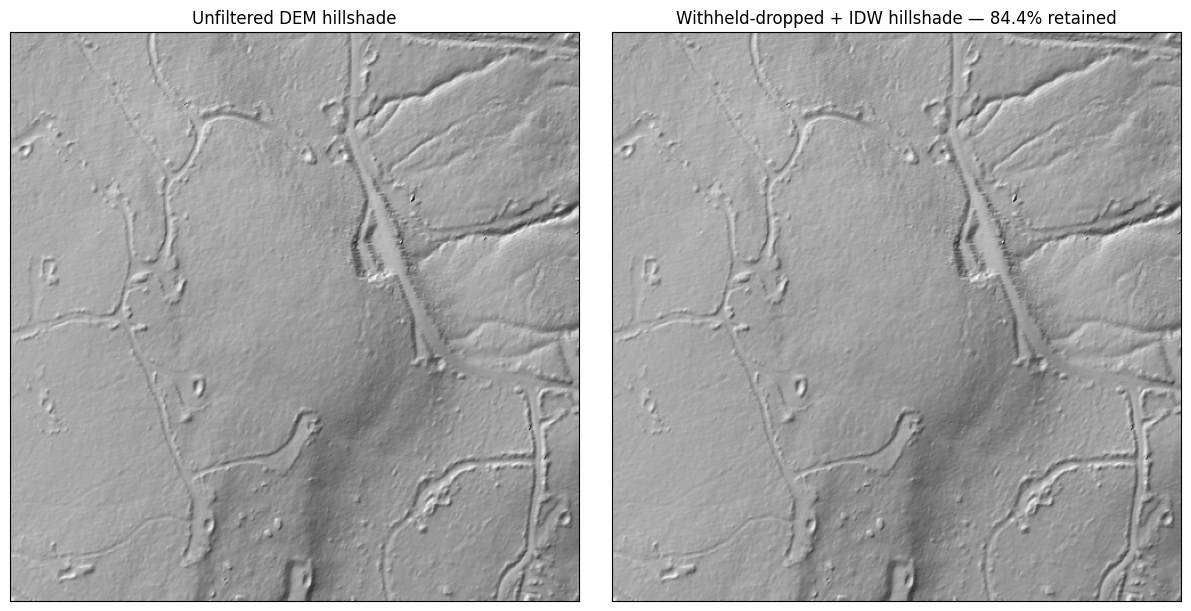

In [6]:
def hillshade(dem, az_deg=315, alt_deg=20):
    ls = LightSource(azdeg=az_deg, altdeg=alt_deg)
    return ls.hillshade(dem, vert_exag=2.0)

def read_dem(path):
    with rasterio.open(path) as ds:
        a = ds.read(1).astype(np.float32)
        nd = ds.nodata
    if nd is not None:
        a = np.where(a == nd, np.nan, a)
    return a

dem_u = read_dem(DEM_UNFILT)
dem_f = read_dem(DEM_FILT)

# Low sun altitude (20 deg) emphasises any periodic stripe pattern.
hs_u = hillshade(np.nan_to_num(dem_u, nan=np.nanmedian(dem_u)), alt_deg=20)
hs_f = hillshade(np.nan_to_num(dem_f, nan=np.nanmedian(dem_f)), alt_deg=20)

fig, axes = plt.subplots(1, 2, figsize=(12, 6), constrained_layout=True)
axes[0].imshow(hs_u, cmap='gray'); axes[0].set_title('Unfiltered DEM hillshade')
axes[1].imshow(hs_f, cmap='gray'); axes[1].set_title(f"Withheld-dropped + IDW hillshade — {stats['retention_pct']:.1f}% retained")
for ax in axes:
    ax.set_xticks([]); ax.set_yticks([])
plt.show()

## 5. Summary

Observed on the 9t mosaic:

- Withheld points dropped: see `stats['withheld_dropped']` above (the 15.57% provider-flagged fraction documented in the design spec).
- Scan-angle points dropped (|angle| > 15°): see `stats['scan_angle_dropped']`.
- Overall retention: `stats['retention_pct']` (~69% expected per spec §4).

Visually, the side-by-side hillshade should show the periodic along-track corduroy texture reduced or eliminated in the filtered panel. Residual artifacts, if any, are attributable to PointSourceId-multiplicity moiré (Tier-2 mitigation; out of scope for this module — see spec §5).